In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

python-dotenv could not parse statement starting at line 34
python-dotenv could not parse statement starting at line 37
python-dotenv could not parse statement starting at line 38
python-dotenv could not parse statement starting at line 40
python-dotenv could not parse statement starting at line 44
python-dotenv could not parse statement starting at line 48
python-dotenv could not parse statement starting at line 56
python-dotenv could not parse statement starting at line 57
python-dotenv could not parse statement starting at line 60
python-dotenv could not parse statement starting at line 61
python-dotenv could not parse statement starting at line 63
python-dotenv could not parse statement starting at line 64
python-dotenv could not parse statement starting at line 65
python-dotenv could not parse statement starting at line 67
python-dotenv could not parse statement starting at line 68
python-dotenv could not parse statement starting at line 71
python-dotenv could not parse statement 

In [5]:
sys.path.append(".")

In [6]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs import FusekiDB, QleverDB, BaseDB
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [7]:
powers = np.arange(0, 4)  # extend on a more powerful machine
sizes = 10**powers

In [8]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-03-26 22:01:52,110 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-03-26 22:01:52,111 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-03-26 22:01:52,111 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-03-26 22:01:52,111 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...


In [9]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode_streaming(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [10]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.058949727565050125, -0.0051073553040623665, 0.09506019204854965, -0.029170090332627296, -0.07172352075576782, 0.036426812410354614, 0.01788988709449768, 0.07774496078491211, -0.01058284193277359, -0.02719942107796669, -0.014839782379567623, 0.004996407311409712, -0.05195301026105881, -0.01563340425491333, -0.0004883587826043367, 0.012572054751217365, -0.043

In [12]:
base_bsbm_set = datasets[2]
db = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_fuseki = FusekiDBNative(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


2026-03-26 22:01:52,599 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test/sparql


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.084

In [13]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.05894972756505012

In [14]:
import os
os.getcwd()

'/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks'

In [20]:
import time

with db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
        noised_tensor = DataTensor.from_numpy(noised_tensor)

        results = db.query_auto(
            noised_tensor,
            query_difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-03-26 22:14:25,600 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 22:14:25,602 - WARNING - DB directory scratch/bsbm/bsbm_2/db already exists, removing locks if any
2026-03-26 22:14:25,602 - INFO - Stopping server!
2026-03-26 22:14:25,602 - INFO - Starting QLever server on port 8031
2026-03-26 22:14:25,603 - INFO - Running command: qlever-server -i test --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4


2026-03-26 22:14:25,605 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test/sparql)
2026-03-26 22:14:26,619 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:00<00:00, 20.81it/s]
2026-03-26 22:14:27,101 - INFO - Stopping server!


Median elapsed time: 0.04660475254058838


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.310433447361
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2811451554298
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2808358371258
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.2735675275326
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2655547857285
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2630172371864
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2572529613972
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.249070957303
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2425014823675
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.026768216863274574, 0.062174364924...",0.237584605813


In [35]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-03-26 19:48:39,403 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-03-26 19:48:41,294 - INFO - Stopping server!
2026-03-26 19:48:41,294 - INFO - Starting Fuseki server port 7031
2026-03-26 19:48:41,295 - ERROR - TENSOR_CP environment variable is not set
2026-03-26 19:48:41,295 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 19:48:41,296 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 19:48:41,296 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 19:48:41,296 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 19:48:41,299 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/test_fuseki/sparql)
2026-03-26 19:48:43,001 - INFO - Server is up and res

,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.31653597950935364
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.29360419511795044
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163147
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285248
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.26435840129852295
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366256714
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.26019686460494995
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.25919830799102783
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",0.24063780903816223
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",0.24026034772396088


In [36]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [37]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-03-26 19:48:44,532 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 19:48:44,533 - WARNING - DB directory scratch/bsbm/bsbm_2/db already exists, removing locks if any
2026-03-26 19:48:44,533 - INFO - Stopping server!
2026-03-26 19:48:44,534 - INFO - Starting QLever server on port 8031
2026-03-26 19:48:44,534 - INFO - Running command: qlever-server -i test --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-03-26 19:48:44,536 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test/sparql)
2026-03-26 19:48:45,548 - INFO - Server is up and responding to queries
2026-03-26 19:48:45,555 - INFO - Stopping server!


   count
0  42417


## Try some timings!

In [21]:
import timeit
import pandas as pd


def test_db(
    power: int,
    size: int,
    db: BaseDB,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> pd.DataFrame:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return pd.DataFrame()
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        # add a small amount of noise to the test tensor to avoid caching effects
        noised_tensor = DataTensor.from_numpy(
            test_tensor.data
            + np.random.normal(scale=0.001, size=test_tensor.shape)
        )

        test_queries = db.get_queries(embedding=noised_tensor)
        q = test_queries[difficulty][query_type]
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    return pd.DataFrame(timings)


timings_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDB] = [
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 16 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                # QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_timings = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat([timings_df, db_timings], ignore_index=True)


2026-03-26 22:14:41,271 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever/sparql
2026-03-26 22:14:41,272 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-26 22:14:41,273 - WARNING - DB directory scratch/bsbm/bsbm_0/db already exists, removing locks if any
2026-03-26 22:14:41,273 - INFO - Stopping server!
2026-03-26 22:14:41,274 - INFO - Starting QLever server on port 8031
2026-03-26 22:14:41,274 - INFO - Running command: qlever-server -i timing-qlever --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-03-26 22:14:41,279 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever/sparql)


Running BDSDM timing for size 1...
Testing QLever Native (Extended) with difficulty easy and query type embedded...


2026-03-26 22:14:42,291 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db QLever Native (Extended): 100%|██████████| 16/16 [00:00<00:00, 62.76it/s]
2026-03-26 22:14:42,549 - INFO - Stopping server!
2026-03-26 22:14:42,550 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-26 22:14:43,670 - INFO - Stopping server!
2026-03-26 22:14:43,670 - INFO - Starting Fuseki server port 7031
2026-03-26 22:14:43,671 - ERROR - TENSOR_CP environment variable is not set
2026-03-26 22:14:43,672 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:14:43,672 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 22:14:43,672 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 22:14:43,673 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:14:43,674 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 22:14:45,420 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db FusekiDB + RDFT

...

2026-03-26 22:14:56,465 - INFO - Stopping server!
2026-03-26 22:14:56,467 - INFO - Starting Fuseki server port 7031
2026-03-26 22:14:56,467 - ERROR - TENSOR_CP environment variable is not set
2026-03-26 22:14:56,468 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:14:56,468 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 22:14:56,468 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 22:14:56,468 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:14:56,471 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 22:14:58,186 - INFO - Server is up and responding to queries
Timing for size 100, difficulty easy, query type embedded, db FusekiDB + RD

Running BDSDM timing for size 1000...
Testing QLever Native (Extended) with difficulty easy and query type embedded...


2026-03-26 22:15:01,885 - INFO - Server is up and responding to queries
Timing for size 1000, difficulty easy, query type embedded, db QLever Native (Extended): 100%|██████████| 16/16 [00:03<00:00,  4.65it/s]
2026-03-26 22:15:05,328 - INFO - Stopping server!
2026-03-26 22:15:05,329 - INFO - Loading dataset into Fuseki server from data/bsbm_3/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-26 22:15:12,637 - INFO - Stopping server!
2026-03-26 22:15:12,639 - INFO - Starting Fuseki server port 7031
2026-03-26 22:15:12,639 - ERROR - TENSOR_CP environment variable is not set
2026-03-26 22:15:12,640 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:15:12,640 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 22:15:12,641 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 22:15:12,642 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-03-26 22:15:12,645 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 22:15:14,393 - INFO - Server is up and responding to queries
Timing for size 1000, difficulty easy, query type embedded, db FusekiDB + R

In [22]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [23]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type
0,None,0,1,0.019155,0,QLever Native (Extended),easy,embedded
1,None,0,1,0.015749,1,QLever Native (Extended),easy,embedded
2,None,0,1,0.014694,2,QLever Native (Extended),easy,embedded
3,None,0,1,0.014439,3,QLever Native (Extended),easy,embedded
4,None,0,1,0.014427,4,QLever Native (Extended),easy,embedded
...,...,...,...,...,...,...,...,...
123,None,3,1000,0.460016,11,FusekiDB + RDFTensor,easy,embedded
124,None,3,1000,0.264094,12,FusekiDB + RDFTensor,easy,embedded
125,None,3,1000,0.263044,13,FusekiDB + RDFTensor,easy,embedded
126,None,3,1000,0.249367,14,FusekiDB + RDFTensor,easy,embedded


In [24]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['QLever Native (Extended)', 'FusekiDB + RDFTensor']
Length: 2, dtype: str

In [25]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [26]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [27]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever Native (Extended)': 'C0', 'FusekiDB + RDFTensor': 'C1'}

/tmp/ipykernel_929760/421834132.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


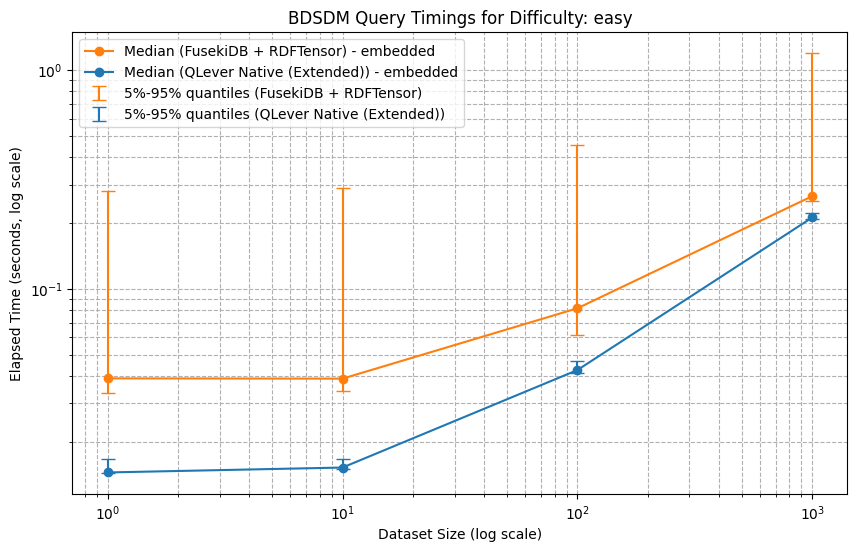

In [28]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()